In [1]:
import sys 
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("src")

from data import load_prices, summary
from risk import (
    price_change,
    rolling_volatility,
    pnl,
    var,
    expected_shortfall,
    run_stress_test,
)
from trading import (
    position,
    signals,
    strategy_pnl,
    evaluate_strategy
)

file_path = "data/Day_ahead_prices.csv"
df = load_prices(file_path)
summary(df)

mean      124.529840
median    102.750000
std       100.616554
min      -500.000000
max       936.280000
dtype: float64

In [2]:
df = price_change(df)

df["rolling_vol"] = rolling_volatility(df, window=24)

Q = 100
df["pnl"] = pnl(df["delta_p"], quantity=Q, direction="long")
var_95 = var(df["pnl"], confidence= 0.95)
var_99 = var(df["pnl"], confidence= 0.99)
es_95 = expected_shortfall(df["pnl"], confidence= 0.95)

print(f"VaR 95%: €{var_95:.2f}")
print(f"VaR 99%: €{var_99:.2f}")
print(f"ES 95%:  €{es_95:.2f}")

stress_table = run_stress_test(df["delta_p"], quantity=Q, direction= "long")
stress_table

# Implied price shocks for VaR levels
implied_shock_95 = -var_95 / Q
implied_shock_99 = -var_99 / Q

# Build the "Normal" and VaR rows in the same schema as run_stress_test's output
extra_rows = pd.DataFrame([
    {"scenario": "Normal",  "price_shock_eur": None,             "position_mwh": Q, "pnl_eur": 0.0},
    {"scenario": "95% VaR", "price_shock_eur": implied_shock_95, "position_mwh": Q, "pnl_eur": -var_95},
    {"scenario": "99% VaR", "price_shock_eur": implied_shock_99, "position_mwh": Q, "pnl_eur": -var_99},
])

es_row = pd.DataFrame([
    {"scenario": "95% Expected Shortfall", "price_shock_eur": -es_95/Q, "position_mwh": Q, "pnl_eur": -es_95}
])


full_stress_table = pd.concat([extra_rows, stress_table], ignore_index=True)
full_stress_table = pd.concat([full_stress_table, es_row], ignore_index=True)
# Formatting
full_stress_table_display = full_stress_table.copy()
full_stress_table_display["price_shock_eur"] = full_stress_table_display["price_shock_eur"].map(
    lambda x: "—" if pd.isna(x) else f"{x:,.2f}"
)

full_stress_table_display["pnl_eur"] = full_stress_table_display["pnl_eur"].map(lambda x: f"{x:,.2f}")

full_stress_table_display

VaR 95%: €3234.80
VaR 99%: €6216.56
ES 95%:  €5281.04


,scenario,price_shock_eur,position_mwh,pnl_eur
0,Normal,—,100,0.00
1,95% VaR,-32.35,100,"-3,234.80"
2,99% VaR,-62.17,100,"-6,216.56"
3,-2sigma shock,-47.49,100,"-4,749.36"
4,-3sigma shock,-71.24,100,"-7,124.04"
5,-4sigma shock,-94.99,100,"-9,498.73"
6,worst historical move,-355.08,100,"-35,508.00"
7,95% Expected Shortfall,-52.81,100,"-5,281.04"


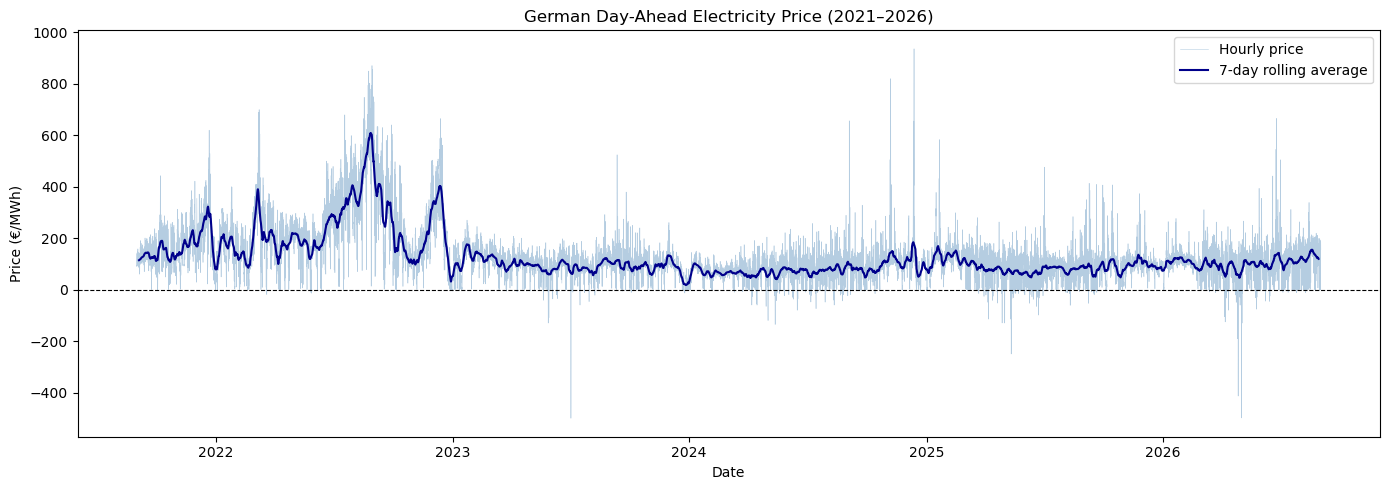

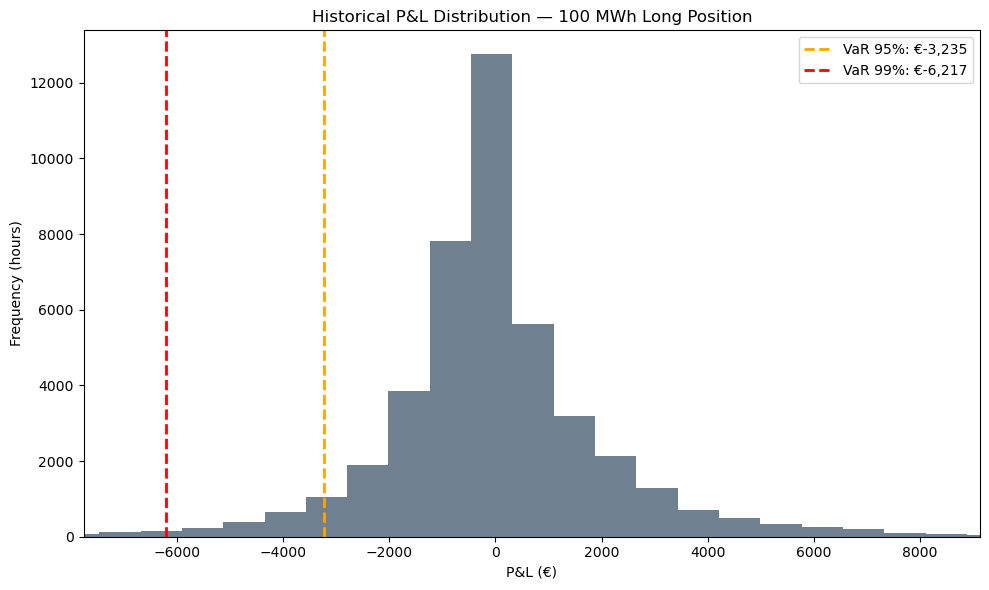

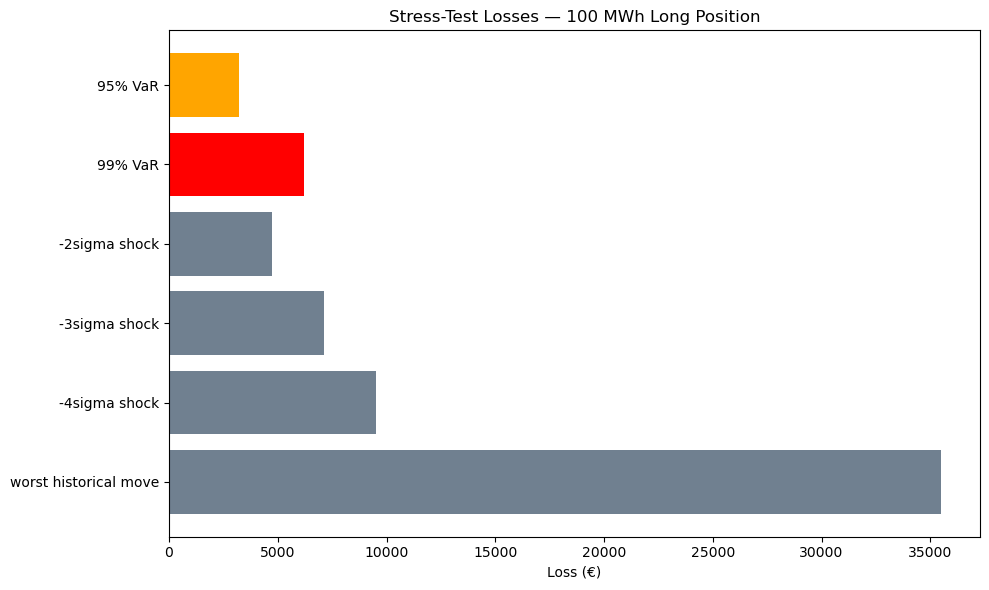

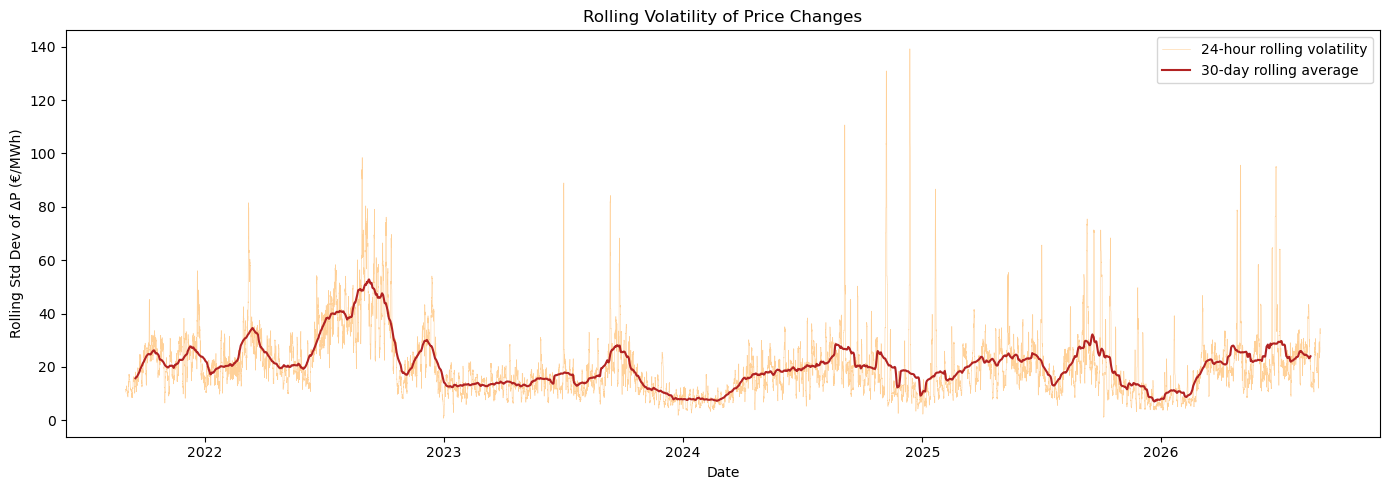

In [ ]:
# Fig 1: Historical price
df["price_smooth"] = df["price_eur_mwh"].rolling(window=168, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["timestamp"], df["price_eur_mwh"], linewidth=0.4, color="steelblue", alpha=0.4, label="Hourly price")
ax.plot(df["timestamp"], df["price_smooth"], linewidth=1.5, color="darkblue", label="7-day rolling average")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("German Day-Ahead Electricity Price (2021–2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (€/MWh)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/electricity_price.pdf", dpi=150)
plt.show()

# Fig 2: Pnl distribution

pnl_clean = df["pnl"].dropna()
x_low, x_high = pnl_clean.quantile([0.005, 0.995])  # trim extreme 0.5% each side for display only

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pnl_clean, bins=100, color="slategray", edgecolor="none")

ax.axvline(-var_95, color="orange", linestyle="--", linewidth=2, label=f"VaR 95%: €{-var_95:,.0f}")
ax.axvline(-var_99, color="red", linestyle="--", linewidth=2, label=f"VaR 99%: €{-var_99:,.0f}")

ax.set_xlim(x_low, x_high)
ax.set_title("Historical P&L Distribution — 100 MWh Long Position")
ax.set_xlabel("P&L (€)")
ax.set_ylabel("Frequency (hours)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/pnl_distribution.pdf", dpi=150)
plt.show()

# Fig 3: Stress-test losses
scenarios = ["95% VaR", "99% VaR"] + stress_table["scenario"].tolist()
losses = [var_95, var_99] + (-stress_table["pnl_eur"]).tolist()  # flip sign to show as positive losses

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["orange", "red"] + ["slategray"] * len(stress_table)
ax.barh(scenarios, losses, color=colors)
ax.set_title("Stress-Test Losses — 100 MWh Long Position")
ax.set_xlabel("Loss (€)")
ax.invert_yaxis()  # largest/first scenario on top
plt.tight_layout()
plt.savefig("figures/risk_stress_test.pdf", dpi=150)
plt.show()

# Fig 4: Volatility
df["vol_smooth"] = df["rolling_vol"].rolling(window=720, center=True).mean()  # ~30 days

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["timestamp"], df["rolling_vol"], linewidth=0.4, color="darkorange", alpha=0.4, label="24-hour rolling volatility")
ax.plot(df["timestamp"], df["vol_smooth"], linewidth=1.5, color="firebrick", label="30-day rolling average")
ax.set_title("Rolling Volatility of Price Changes")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Std Dev of ΔP (€/MWh)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/volatility.pdf", dpi=150)
plt.show()


In [4]:
quantities = [25, 50, 100, 250, 500]

sensitivity_rows = []
for Q_test in quantities:
    pnl_test = pnl(df["delta_p"], quantity=Q_test, direction="long")
    var_95_test = var(pnl_test, confidence=0.95)
    var_99_test = var(pnl_test, confidence=0.99)
    es_95_test = expected_shortfall(pnl_test, confidence=0.95)

    sensitivity_rows.append({
        "quantity_mwh": Q_test,
        "var_95_eur": var_95_test,
        "var_99_eur": var_99_test,
        "es_95_eur": es_95_test,
    })

sensitivity_table = pd.DataFrame(sensitivity_rows)
sensitivity_table

,quantity_mwh,var_95_eur,var_99_eur,es_95_eur
0,25,808.7,1554.14,1320.260835
1,50,1617.4,3108.28,2640.521670
2,100,3234.8,6216.56,5281.043339
3,250,8087.0,15541.40,13202.608349
4,500,16174.0,31082.80,26405.216697


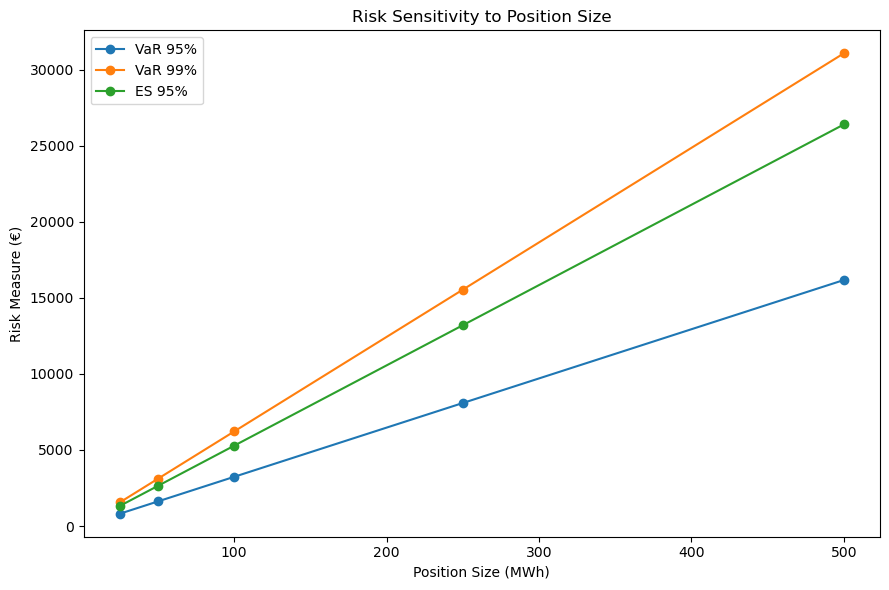

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(sensitivity_table["quantity_mwh"], sensitivity_table["var_95_eur"], marker="o", label="VaR 95%")
ax.plot(sensitivity_table["quantity_mwh"], sensitivity_table["var_99_eur"], marker="o", label="VaR 99%")
ax.plot(sensitivity_table["quantity_mwh"], sensitivity_table["es_95_eur"], marker="o", label="ES 95%")

ax.set_title("Risk Sensitivity to Position Size")
ax.set_xlabel("Position Size (MWh)")
ax.set_ylabel("Risk Measure (€)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/position_sensitivity.pdf", dpi=150)
plt.show()

In [6]:
ratio = sensitivity_table["var_95_eur"] / sensitivity_table["quantity_mwh"]
print(ratio)

0    32.348
1    32.348
2    32.348
3    32.348
4    32.348
dtype: float64


In [7]:
# Build the position (documentation/bookkeeping)
pos = position(quantity=Q, direction="long")

# Generate long/short signals based on price percentiles
sig = signals(df, price_col="price_eur_mwh", low_pct=0.25, high_pct=0.75)

# Shift signal by 1 to avoid lookahead: today's signal trades tomorrow's price change
strategy_returns = strategy_pnl(df["delta_p"], sig.shift(1), quantity=Q)

# Evaluate
strategy_results = evaluate_strategy(strategy_returns)
strategy_results

{'total_pnl': np.float64(6585116.0),
 'average_pnl': np.float64(150.26620724277205),
 'volatility': 2070.0968055324693,
 'max_drawdown': -76010.0,
 'num_trades': np.int64(21775),
 'win_rate': 0.548105625717566}

In [8]:
strategy_var_95 = var(strategy_returns, confidence=0.95)
strategy_es_95 = expected_shortfall(strategy_returns, confidence=0.95)

print(f"Strategy VaR 95%: €{strategy_var_95:,.2f}")
print(f"Strategy ES 95%:  €{strategy_es_95:,.2f}")

Strategy VaR 95%: €2,459.00
Strategy ES 95%:  €4,966.68


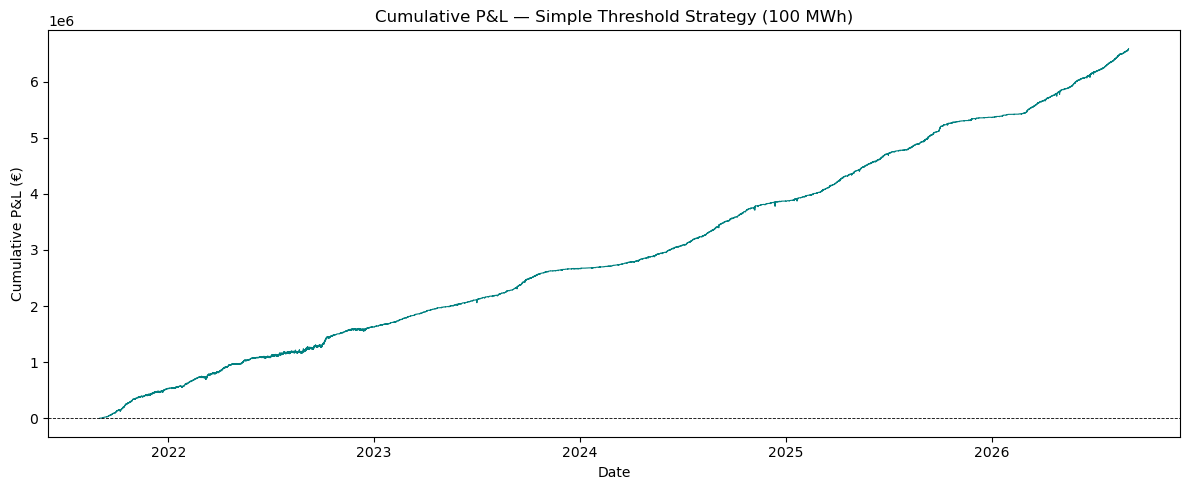

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["timestamp"], strategy_returns.cumsum(), linewidth=0.8, color="teal")
ax.set_title("Cumulative P&L — Simple Threshold Strategy (100 MWh)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative P&L (€)")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
plt.tight_layout()
plt.savefig("figures/strategy_cumulative_pnl.pdf", dpi=150)
plt.show()

In [10]:
pct_negative = (df["price_eur_mwh"] < 0).mean() * 100
count_negative = (df["price_eur_mwh"] < 0).sum()

print(f"Negative-price hours: {count_negative} out of {len(df)} ({pct_negative:.2f}%)")

Negative-price hours: 1836 out of 43824 (4.19%)
